# Analyse Exploratoire des Données - Projet Alzheimer

## Prediction precoce d'Alzheimer

**Objectif Principal**
- Comprendre la structure et qualite des donnees
- Identifier les patterns et correlations cles
- Detecter valeurs manquantes et anomalies
- Préparer recommendations pour modelisation

**Dataset**: ADNI (Alzheimer's Disease Neuroimaging Initiative)
- Patients: ~4000 
- Observations longitudinales : ~16000
- Variables: ~500+ colonnes
- Categories des variables : démographique, cognitive, physiologique, imagerie 

**Date**: 25 mars 2026

## 1. Import des librairies

In [1]:
from supabase import create_client

# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go


## 2. Chargement des données

In [2]:
# récupération des mots de passe et URL
url = os.environ.get("SUPABASE_URL")
key = os.environ.get("SUPABASE_SERVICE_ROLE_KEY")
 
# connexion
supabase = create_client(url, key)
 
# récupération de toutes les lignes
batch_size = 1000
start = 0
rows = []

while True:
    end = start + batch_size - 1
    batch = supabase.table("ALZ_BRONZE").select("*").range(start, end).execute()

    if not batch.data:
        break

    rows.extend(batch.data)
    start += batch_size

# transformation en DataFrame
df = pd.DataFrame(rows)


print("Données chargées.")

Données chargées.


## 3. Paramétrages divers

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
sns.set_palette("YlGnBu")

## 4. Vue d’ensemble
Le dataset contient 15987 observations et 584 variables, principalement numériques.

In [4]:
df.shape

(15987, 584)

In [5]:
# =========================================
# Informations générales : données extrait ADNI
# Chaque ligne correspond à une visite clinique d’un même patient RID et VISCODE
# Présence de scores cognitifs : TOTSCORE = 10.67, TOTAL13 = 18.67, CDRSB
# Présence de diagnostics cliniques : DIAGNOSIS, DXNORM, DXAD, ...
# Présence de données IRM volumétriques : ST101SV = 2626.2, ST102CV = 3362.0, ... en mm³.
# Présence de métadonnées IRM : STATUS = partial, FIELD_STRENGTH = 1.5T, FSVER = 7.2.0
# Beaucoup de valeurs manquantes : NaN, -4.0 (code ADNI pour missing / not applicable)
# =========================================
#
df.head()


,PHASE,RID,VISCODE,PTID,VISCODE2,VISDATE,TOTSCORE,TOTAL13,Id,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,update_stamp,CDSOURCE,CDVERSION,SPID,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,CDGLOBAL,CDRSB,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,DXMDES,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,DXMPTR5,DXMPTR6,DXMDUE,DXMOTHET,DXDSEV,DXDDUE,DXAD,DXAPP,DXAPROB,DXAPOSS,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,DXODES,DXCONFID,MOTHALIVE,MOTHAGE,MOTHDEM,MOTHAD,MOTHSXAGE,FATHALIVE,FATHAGE,FATHDEM,FATHAD,FATHSXAGE,IHNUM,IHSYMPTOM,IHDESC,IHSURG,IHSURGDATE,IHPRESENT,IHCHRON,IHSEVER,IHDTONSET,IHONGOING,IHCEASE,IHCOMM,MHSOURCE,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH14BALCH,MH14CALCH,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,MH17MALI,MH18SURG,MH19OTHR,DONE,NDREASON,SOURCE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,MMAREA,MMSTATE,WORDLIST,WORD1,WORD2,WORD3,MMTRIALS,MMD,MML,MMR,MMO,MMW,MMLTR1,MMLTR2,MMLTR3,MMLTR4,MMLTR5,MMLTR6,MMLTR7,WORLDSCORE,WORD1DL,WORD2DL,WORD3DL,MMWATCH,MMPENCIL,MMREPEAT,MMHAND,MMFOLD,MMONFLR,MMREAD,MMWRITE,MMDRAW,MMSCORE,PXGENAPP,PXHEADEY,PXNECK,PXCHEST,PXHEART,PXABDOM,PXEXTREM,PXEDEMA,PXPERIPH,PXSKIN,PXMUSCUL,PXBACK,PXOTHER,PXABNORM,PTSOURCE,PTGENDER,PTDOB,PTDOBYY,PTHAND,PTMARRY,PTEDUCAT,PTWORKHS,PTWORK,PTNOTRT,PTRTYR,PTHOME,PTTLANG,PTPLANG,PTADBEG,PTCOGBEG,PTADDX,PTETHCAT,PTRACCAT,PTIDENT,PTORIENT,PTORIENTOT,PTENGSPK,PTNLANG,PTENGSPKAGE,PTCLANG,PTLANGSP,PTLANGWR,PTSPTIM,PTSPOTTIM,PTLANGPR1,PTLANGSP1,PTLANGRD1,PTLANGWR1,PTLANGUN1,PTLANGPR2,PTLANGSP2,PTLANGRD2,PTLANGWR2,PTLANGUN2,PTLANGPR3,PTLANGSP3,PTLANGRD3,PTLANGWR3,PTLANGUN3,PTLANGPR4,PTLANGSP4,PTLANGRD4,PTLANGWR4,PTLANGUN4,PTLANGPR5,PTLANGSP5,PTLANGRD5,PTLANGWR5,PTLANGUN5,PTLANGPR6,PTLANGSP6,PTLANGRD6,PTLANGWR6,PTLANGUN6,PTLANGTTL,PTETHCATH,PTASIAN,PTOPI,PTBORN,PTBIRPL,PTIMMAGE,PTIMMWHY,PTBIRPR,PTBIRGR,IMAGEUID,FIELD_STRENGTH,RUNDATE,STATUS,FSVER,OVERALLQC,TEMPQC,FRONTQC,PARQC,INSULAQC,OCCQC,BGQC,CWMQC,VENTQC,HIPPOQC,ST101SV,ST102CV,ST102SA,ST102TA,ST102TS,ST103CV,ST103SA,ST103TA,ST103TS,ST104CV,ST104SA,ST104TA,ST104TS,ST105CV,ST105SA,ST105TA,ST105TS,ST106CV,ST106SA,ST106TA,ST106TS,ST107CV,ST107SA,ST107TA,ST107TS,ST108CV,ST108SA,ST108TA,ST108TS,ST109CV,ST109SA,ST109TA,ST109TS,ST10CV,ST110CV,ST110SA,ST110TA,ST110TS,ST111CV,ST111SA,ST111TA,ST111TS,ST112SV,ST113CV,ST113SA,ST113TA,ST113TS,ST114CV,ST114SA,ST114TA,ST114TS,ST115CV,ST115SA,ST115TA,ST115TS,ST116CV,ST116SA,ST116TA,ST116TS,ST117CV,ST117SA,ST117TA,ST117TS,ST118CV,ST118SA,ST118TA,ST118TS,ST119CV,ST119SA,ST119TA,ST119TS,ST11SV,ST120SV,ST121CV,ST121SA,ST121TA,ST121TS,ST124SV,ST125SV,ST127SV,ST128SV,ST129CV,ST129SA,ST129TA,ST129TS,ST12SV,ST130CV,ST130SA,ST130TA,ST130TS,ST13CV,ST13SA,ST13TA,ST13TS,ST14CV,ST14SA,ST14TA,ST14TS,ST15CV,ST15SA,ST15TA,ST15TS,ST16SV,ST17SV,ST18SV,ST1SV,ST21SV,ST23CV,ST23SA,ST23TA,ST23TS,ST24CV,ST24SA,ST24TA,ST24TS,ST25CV,ST25SA,ST25TA,ST25TS,ST26CV,ST26SA,ST26TA,ST26TS,ST28SA,ST29SV,ST2SV,ST30SV,ST31CV,ST31SA,ST31TA,ST31TS,ST32CV,ST32SA,ST32TA,ST32TS,ST34CV,ST34SA,ST34TA,ST34TS,ST35CV,ST35SA,ST35TA,ST35TS,ST36CV,ST36SA,ST36TA,ST36TS,ST37SV,ST38CV,ST38SA,ST38TA,ST38TS,ST39CV,ST39SA,ST39TA,ST39TS,ST3SV,ST40CV,ST40SA,ST40TA,ST40TS,ST42SV,ST43CV,ST43SA,ST43TA,ST43TS,ST44CV,ST44SA,ST44TA,ST44TS,ST45CV,ST45SA,ST45TA,ST45TS,ST46CV,ST46SA,ST46TA,ST46TS,ST47CV,ST47SA,ST47TA,ST47TS,ST48CV,ST48SA,ST48TA,ST48TS,ST49CV,ST49SA,ST49TA,ST49TS,ST4SV,ST50CV,ST50SA,ST50TA,ST50TS,ST51CV,ST51SA,ST51TA,ST51TS,ST52CV,ST52SA,ST52TA,ST52TS,ST53SV,ST54CV,ST54SA,ST54TA,ST54TS,ST55CV,ST55SA,ST55TA,ST55TS,ST56CV,ST56SA,ST56TA,ST56TS,ST57CV,ST57SA,ST57TA,ST57TS,ST58CV,ST58SA,ST58TA,ST58TS,ST59CV,ST59SA,ST59TA,ST59TS,ST5SV,ST60CV,ST60SA,ST60TA,ST60TS,ST61SV,ST62CV,ST62SA,ST62TA,ST62TS,ST65SV,ST66SV,ST68SV,ST69SV,ST6SV,ST70SV,ST71SV,ST72CV,ST72SA,ST72TA,ST72TS,ST73CV,ST73SA,ST73TA,ST73TS,ST74CV,ST74SA,ST74TA,ST74TS,ST75SV,ST76SV,ST77SV,ST7SV,ST80SV,ST82CV,ST82SA,ST82TA,ST82T

In [ ]:
# Informations générales
# 15 987 lignes : un dataset assez large
# 584 colonnes → extrêmement large (high‑dimensional)
# La grande majorité des colonnes sont numériques 
# 71.2 MB C’est lourd pour un DataFrame pandas, mais encore gérable.
# Très riche mais très bruité (données clinique normal)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15987 entries, 0 to 15986
Columns: 584 entries, PHASE to VSHGTSC
dtypes: float64(526), int64(4), str(54)
memory usage: 71.2 MB


In [8]:
df.dtypes

PHASE                       str
RID                       int64
VISCODE                     str
PTID                        str
VISCODE2                    str
VISDATE                     str
TOTSCORE                float64
TOTAL13                 float64
Id                        int64
SITEID                    int64
USERDATE                    str
USERDATE2                   str
DD_CRF_VERSION_LABEL        str
LANGUAGE_CODE               str
update_stamp                str
CDSOURCE                float64
CDVERSION               float64
SPID                    float64
CDMEMORY                float64
CDORIENT                float64
CDJUDGE                 float64
CDCOMMUN                float64
CDHOME                  float64
CDCARE                  float64
CDGLOBAL                float64
CDRSB                   float64
EXAMDATE                    str
DIAGNOSIS                 int64
DXNORM                  float64
DXNODEP                 float64
DXMCI                   float64
DXMDES  

In [ ]:
# Types de variables
# Les 4 colonnes int64 sont probablement des identifiants purs ou des compteurs sans décimales (RID, SITEID, etc.). 
# Les 526 float64 
# le fait que tout soit en float64 suggère deux choses :
# La présence des valeurs -4 et 9999 a forcé pandas à upcast en float (pandas convertit en float dès qu'il y a des NaN ou des valeurs mixtes) Ou ces colonnes n'ont jamais été castées proprement à l'import
#/!\ attention aux features qualitative
df.dtypes.value_counts()

float64    526
str         54
int64        4
Name: count, dtype: int64

In [21]:
# Statistiques descriptives
# Valeurs sentinelles (-4). Le dataset utilise manifestement -4 comme code "missing" ou "not applicable" dans de nombreuses variables numériques (on le voit dans les min, Q25, et même les moyennes tirées vers le bas).
# Valeur 9999. On la retrouve dans PTHOME et PTRTYR, autre code sentinelle probable pour "inconnu" ou "non renseigné".
# Les colonnes CDGLOBAL, CDRSB (Clinical Dementia Rating), MMSCORE (Mini-Mental State Examination), et DIAGNOSIS sont probablement les variables cibles pour un modèle de prédiction ou de classification de la démence/MCI/Alzheimer.
# Les colonnes ST**SV, ST**CV, ST**SA, ST**TA correspondent à des volumes, courbures et surfaces de régions cérébrales issues du pipeline FreeSurfer — des features d'imagerie très riches mais à forte dimensionnalité (~500+ colonnes).
# Les variables VSWEIGHT, VSHEIGHT, VSBPSYS, VSBPDIA, VSPULSE, VSTEMP sont des constantes vitales à distributions raisonnables (ex. pression systolique moyenne ~133 mmHg, pouls ~65).
# Certaines colonnes d'imagerie présentent des distributions très larges (ex. ST1SV avec min ~427k, max ~1.5M),
# VISCODE 31 car classifié bl — baseline (visite initiale), m06, m12, m18, m24... — suivi à 6 mois, 12 mois, etc.,sc — screening,v01, v02... — dans certaines phases
df.describe(include='all')

,PHASE,RID,VISCODE,PTID,VISCODE2,VISDATE,TOTSCORE,TOTAL13,Id,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,update_stamp,CDSOURCE,CDVERSION,SPID,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,CDGLOBAL,CDRSB,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,DXMDES,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,DXMPTR5,DXMPTR6,DXMDUE,DXMOTHET,DXDSEV,DXDDUE,DXAD,DXAPP,DXAPROB,DXAPOSS,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,DXODES,DXCONFID,MOTHALIVE,MOTHAGE,MOTHDEM,MOTHAD,MOTHSXAGE,FATHALIVE,FATHAGE,FATHDEM,FATHAD,FATHSXAGE,IHNUM,IHSYMPTOM,IHDESC,IHSURG,IHSURGDATE,IHPRESENT,IHCHRON,IHSEVER,IHDTONSET,IHONGOING,IHCEASE,IHCOMM,MHSOURCE,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH14BALCH,MH14CALCH,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,MH17MALI,MH18SURG,MH19OTHR,DONE,NDREASON,SOURCE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,MMAREA,MMSTATE,WORDLIST,WORD1,WORD2,WORD3,MMTRIALS,MMD,MML,MMR,MMO,MMW,MMLTR1,MMLTR2,MMLTR3,MMLTR4,MMLTR5,MMLTR6,MMLTR7,WORLDSCORE,WORD1DL,WORD2DL,WORD3DL,MMWATCH,MMPENCIL,MMREPEAT,MMHAND,MMFOLD,MMONFLR,MMREAD,MMWRITE,MMDRAW,MMSCORE,PXGENAPP,PXHEADEY,PXNECK,PXCHEST,PXHEART,PXABDOM,PXEXTREM,PXEDEMA,PXPERIPH,PXSKIN,PXMUSCUL,PXBACK,PXOTHER,PXABNORM,PTSOURCE,PTGENDER,PTDOB,PTDOBYY,PTHAND,PTMARRY,PTEDUCAT,PTWORKHS,PTWORK,PTNOTRT,PTRTYR,PTHOME,PTTLANG,PTPLANG,PTADBEG,PTCOGBEG,PTADDX,PTETHCAT,PTRACCAT,PTIDENT,PTORIENT,PTORIENTOT,PTENGSPK,PTNLANG,PTENGSPKAGE,PTCLANG,PTLANGSP,PTLANGWR,PTSPTIM,PTSPOTTIM,PTLANGPR1,PTLANGSP1,PTLANGRD1,PTLANGWR1,PTLANGUN1,PTLANGPR2,PTLANGSP2,PTLANGRD2,PTLANGWR2,PTLANGUN2,PTLANGPR3,PTLANGSP3,PTLANGRD3,PTLANGWR3,PTLANGUN3,PTLANGPR4,PTLANGSP4,PTLANGRD4,PTLANGWR4,PTLANGUN4,PTLANGPR5,PTLANGSP5,PTLANGRD5,PTLANGWR5,PTLANGUN5,PTLANGPR6,PTLANGSP6,PTLANGRD6,PTLANGWR6,PTLANGUN6,PTLANGTTL,PTETHCATH,PTASIAN,PTOPI,PTBORN,PTBIRPL,PTIMMAGE,PTIMMWHY,PTBIRPR,PTBIRGR,IMAGEUID,FIELD_STRENGTH,RUNDATE,STATUS,FSVER,OVERALLQC,TEMPQC,FRONTQC,PARQC,INSULAQC,OCCQC,BGQC,CWMQC,VENTQC,HIPPOQC,ST101SV,ST102CV,ST102SA,ST102TA,ST102TS,ST103CV,ST103SA,ST103TA,ST103TS,ST104CV,ST104SA,ST104TA,ST104TS,ST105CV,ST105SA,ST105TA,ST105TS,ST106CV,ST106SA,ST106TA,ST106TS,ST107CV,ST107SA,ST107TA,ST107TS,ST108CV,ST108SA,ST108TA,ST108TS,ST109CV,ST109SA,ST109TA,ST109TS,ST10CV,ST110CV,ST110SA,ST110TA,ST110TS,ST111CV,ST111SA,ST111TA,ST111TS,ST112SV,ST113CV,ST113SA,ST113TA,ST113TS,ST114CV,ST114SA,ST114TA,ST114TS,ST115CV,ST115SA,ST115TA,ST115TS,ST116CV,ST116SA,ST116TA,ST116TS,ST117CV,ST117SA,ST117TA,ST117TS,ST118CV,ST118SA,ST118TA,ST118TS,ST119CV,ST119SA,ST119TA,ST119TS,ST11SV,ST120SV,ST121CV,ST121SA,ST121TA,ST121TS,ST124SV,ST125SV,ST127SV,ST128SV,ST129CV,ST129SA,ST129TA,ST129TS,ST12SV,ST130CV,ST130SA,ST130TA,ST130TS,ST13CV,ST13SA,ST13TA,ST13TS,ST14CV,ST14SA,ST14TA,ST14TS,ST15CV,ST15SA,ST15TA,ST15TS,ST16SV,ST17SV,ST18SV,ST1SV,ST21SV,ST23CV,ST23SA,ST23TA,ST23TS,ST24CV,ST24SA,ST24TA,ST24TS,ST25CV,ST25SA,ST25TA,ST25TS,ST26CV,ST26SA,ST26TA,ST26TS,ST28SA,ST29SV,ST2SV,ST30SV,ST31CV,ST31SA,ST31TA,ST31TS,ST32CV,ST32SA,ST32TA,ST32TS,ST34CV,ST34SA,ST34TA,ST34TS,ST35CV,ST35SA,ST35TA,ST35TS,ST36CV,ST36SA,ST36TA,ST36TS,ST37SV,ST38CV,ST38SA,ST38TA,ST38TS,ST39CV,ST39SA,ST39TA,ST39TS,ST3SV,ST40CV,ST40SA,ST40TA,ST40TS,ST42SV,ST43CV,ST43SA,ST43TA,ST43TS,ST44CV,ST44SA,ST44TA,ST44TS,ST45CV,ST45SA,ST45TA,ST45TS,ST46CV,ST46SA,ST46TA,ST46TS,ST47CV,ST47SA,ST47TA,ST47TS,ST48CV,ST48SA,ST48TA,ST48TS,ST49CV,ST49SA,ST49TA,ST49TS,ST4SV,ST50CV,ST50SA,ST50TA,ST50TS,ST51CV,ST51SA,ST51TA,ST51TS,ST52CV,ST52SA,ST52TA,ST52TS,ST53SV,ST54CV,ST54SA,ST54TA,ST54TS,ST55CV,ST55SA,ST55TA,ST55TS,ST56CV,ST56SA,ST56TA,ST56TS,ST57CV,ST57SA,ST57TA,ST57TS,ST58CV,ST58SA,ST58TA,ST58TS,ST59CV,ST59SA,ST59TA,ST59TS,ST5SV,ST60CV,ST60SA,ST60TA,ST60TS,ST61SV,ST62CV,ST62SA,ST62TA,ST62TS,ST65SV,ST66SV,ST68SV,ST69SV,ST6SV,ST70SV,ST71SV,ST72CV,ST72SA,ST72TA,ST72TS,ST73CV,ST73SA,ST73TA,ST73TS,ST74CV,ST74SA,ST74TA,ST74TS,ST75SV,ST76SV,ST77SV,ST7SV,ST80SV,ST82CV,ST82SA,ST82TA,ST82T

## 5. Analyse de la cible
On vérifie l’équilibre des classes (important pour le choix modèle).

In [35]:
# Analyse de la cible = DIAGNOSIS
# Prediction de l'Alzeimer précosément au vue d'une classe AD déséquilibré il serait envisagable de regrouper les classes 2 et 3
# MCI patient à risque et de garder la classe CN seul 
diagnosis_labels = {
    1: '1-Cognitif normal (CN)',
    2: '2-MCI',
    3: '3-Maladie d\'Alzheimer (AD)'
}

df['DIAGNOSIS'].map(diagnosis_labels).value_counts()



DIAGNOSIS
2-MCI                         6610
1-Cognitif normal (CN)        6369
3-Maladie d'Alzheimer (AD)    3008
Name: count, dtype: int64

In [66]:
print("Visualisation de la target en pourcentage :\n", df['DIAGNOSIS'].value_counts(normalize=True))

Visualisation de la target en pourcentage :
 DIAGNOSIS
2    0.413461
1    0.398386
3    0.188153
Name: proportion, dtype: float64


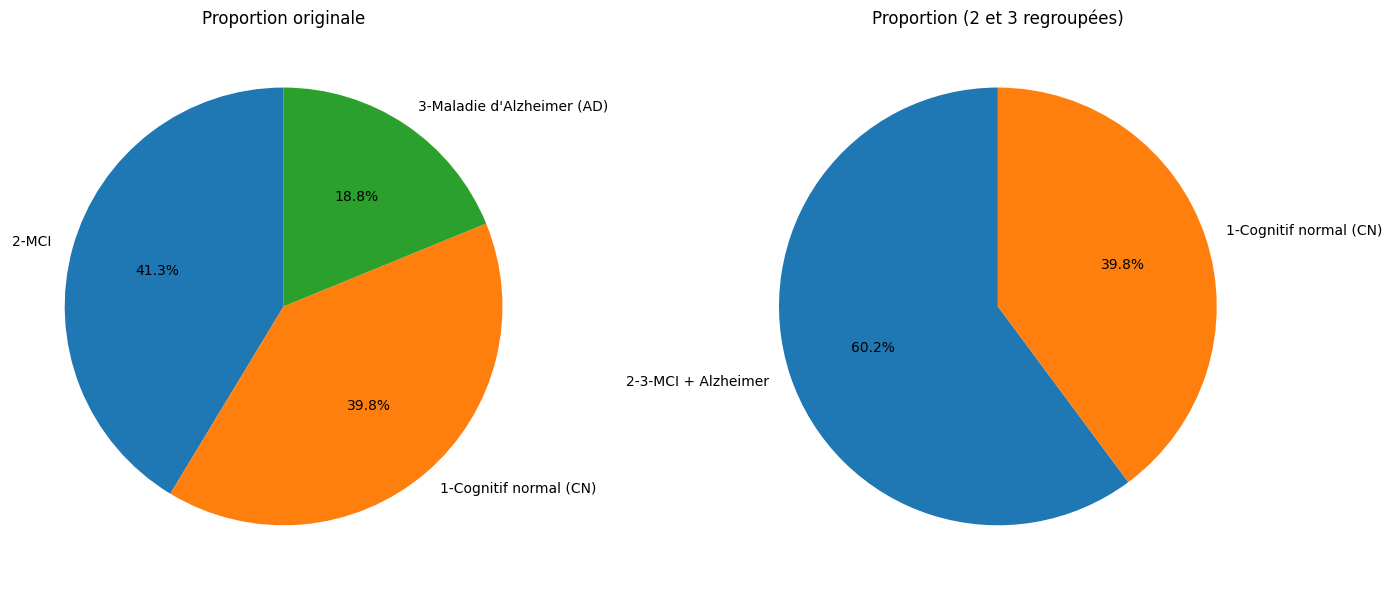

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Camembert original
df['DIAGNOSIS'].map(diagnosis_labels).value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, ax=axes[0]
)
axes[0].set_title("Proportion originale")

# Camembert regroupé
df['DIAGNOSIS'].replace({2: '2-3', 3: '2-3'}).map({
    1: '1-Cognitif normal (CN)',
    '2-3': '2-3-MCI + Alzheimer'
}).value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, ax=axes[1]
)
axes[1].set_title("Proportion (2 et 3 regroupées)")

plt.tight_layout()
plt.show()


## 6. Valeurs manquantes
J’identifie les variables nécessitant un traitement (imputation ou suppression).

In [20]:
#Analyse des Nan recommandation supprimer les nan avec un seuil supperieur à 30%
(df.isna().sum()/df.shape[0]).sort_values(ascending=False)

PTOPI                   0.999875
PTORIENTOT              0.999687
PTLANGWR6               0.999562
PTLANGSP6               0.999562
PTLANGUN6               0.999562
PTLANGRD6               0.999562
PTLANGRD5               0.998624
PTLANGWR5               0.998624
PTLANGUN5               0.998624
PTLANGPR6               0.998624
PTLANGSP5               0.998624
PTLANGPR5               0.997310
PTLANGRD4               0.997310
PTLANGUN4               0.997310
PTLANGWR4               0.997310
PTLANGSP4               0.997310
PTADBEG                 0.997060
MMLTR7                  0.995747
NDREASON                0.995621
PTASIAN                 0.995309
MH14AALCH               0.994933
PTLANGWR3               0.994871
PTLANGRD3               0.994871
PTLANGPR4               0.994808
PTLANGSP3               0.994808
PTLANGUN3               0.994808
ST8SV                   0.994245
MMLTR6                  0.994120
PTETHCATH               0.991556
PTENGSPKAGE             0.990617
PTIMMAGE  

In [ ]:
# recommandation modification des -1, -4, 9999 en NAN
# cumul des Nan -4 -1 et 9999
(((df.isna()) | (df == -1) | (df == -4) | (df == 9999)).sum() / df.shape[0]).sort_values(ascending=False)



PTADBEG                 1.000000
PTOPI                   0.999875
DXPATYP                 0.999875
DXPCOG                  0.999750
PTORIENTOT              0.999687
DXPDES                  0.999625
PTLANGSP6               0.999562
PTLANGUN6               0.999562
PTLANGRD6               0.999562
PTLANGWR6               0.999562
DXOTHDEM                0.999500
MH15ADRUG               0.998937
MH15BDRUG               0.998937
PTLANGUN5               0.998624
PTLANGWR5               0.998624
PTLANGSP5               0.998624
PTLANGPR6               0.998624
PTLANGRD5               0.998624
PTLANGWR4               0.997310
PTLANGSP4               0.997310
PTLANGPR5               0.997310
PTLANGRD4               0.997310
PTLANGUN4               0.997310
DXODES                  0.996310
MMLTR7                  0.995747
NDREASON                0.995621
PTASIAN                 0.995309
MH14BALCH               0.994933
MH14AALCH               0.994933
MH14CALCH               0.994933
PTLANGRD3 

In [25]:
# % de NaN par colonne
missing_ratio = df.isna().mean() * 100
missing_ratio = missing_ratio.sort_values(ascending=False)

# Colonnes avec >= 70% de NaN
cols_high_nan = missing_ratio[missing_ratio >= 70].index.tolist()

print("Colonnes à fort taux de NaN :", cols_high_nan)
print("Nombre de colonnes à fort taux de NaN :", len(cols_high_nan))


Colonnes à fort taux de NaN : ['PTOPI', 'PTORIENTOT', 'PTLANGWR6', 'PTLANGSP6', 'PTLANGUN6', 'PTLANGRD6', 'PTLANGRD5', 'PTLANGWR5', 'PTLANGUN5', 'PTLANGPR6', 'PTLANGSP5', 'PTLANGPR5', 'PTLANGRD4', 'PTLANGUN4', 'PTLANGWR4', 'PTLANGSP4', 'PTADBEG', 'MMLTR7', 'NDREASON', 'PTASIAN', 'MH14AALCH', 'PTLANGWR3', 'PTLANGRD3', 'PTLANGPR4', 'PTLANGSP3', 'PTLANGUN3', 'ST8SV', 'MMLTR6', 'PTETHCATH', 'PTENGSPKAGE', 'PTIMMAGE', 'PTBIRPL', 'PTIMMWHY', 'PTLANGWR2', 'PTLANGSP2', 'PTLANGUN2', 'PTLANGRD2', 'PTLANGPR3', 'IHCOMM', 'PTLANGSP1', 'PTLANGUN1', 'PTLANGWR1', 'PTLANGRD1', 'PTLANGTTL', 'PTLANGPR2', 'PTLANGPR1', 'FATHSXAGE', 'FATHAD', 'VSHGTSC', 'ST68SV', 'MOTHSXAGE', 'MOTHAD', 'PTORIENT', 'OVERALLQC', 'FRONTQC', 'PARQC', 'OCCQC', 'INSULAQC', 'BGQC', 'HIPPOQC', 'CWMQC', 'VENTQC', 'TEMPQC', 'PTWORK', 'PTIDENT', 'PTENGSPK', 'PTSPTIM', 'PTNLANG', 'PTLANGWR', 'PTLANGSP', 'PTSPOTTIM', 'PTCLANG', 'PTBIRGR', 'PTBIRPR', 'PTBORN', 'MH15ADRUG', 'MH15BDRUG', 'IHCEASE', 'MH14CALCH', 'MHSOURCE', 'MH18SURG', 'MH6

## 7. Distribution des variables

In [40]:
#Certains float seraient plutôt des variables catégorielles MMDATE, WORLD1DL, etc ...

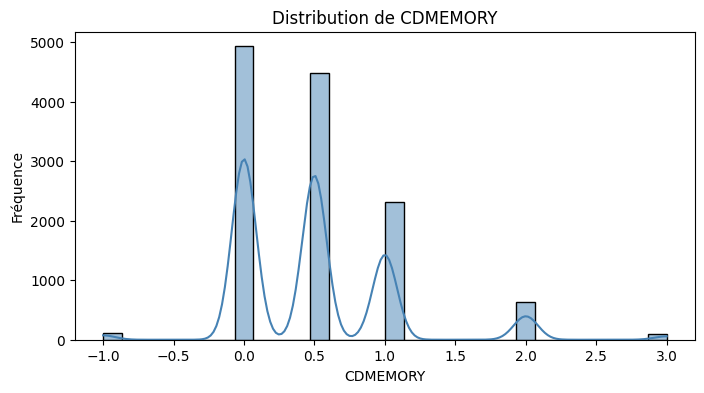

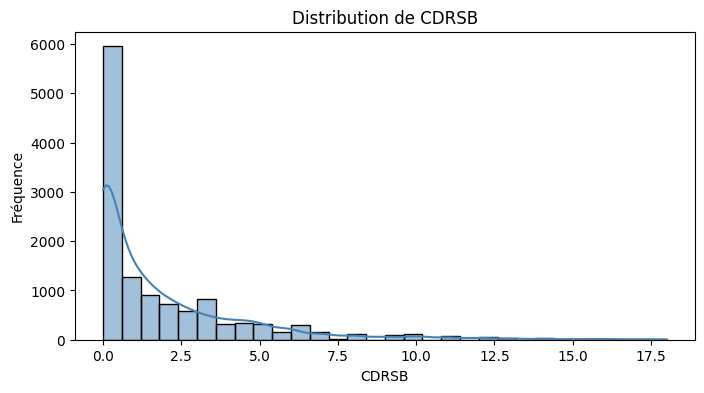

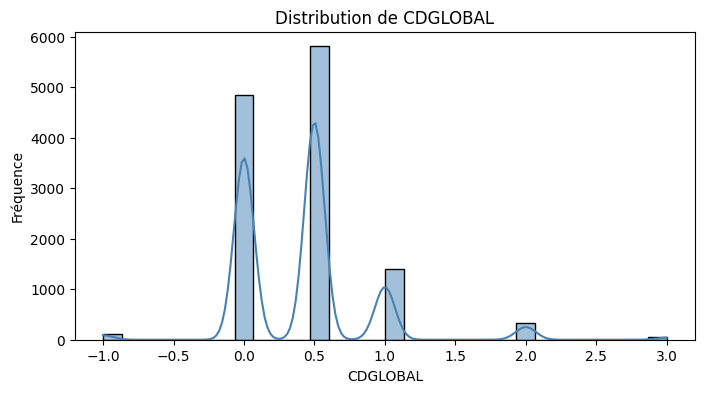

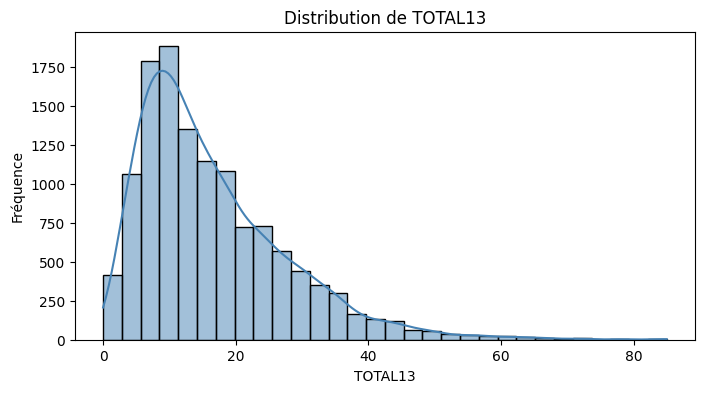

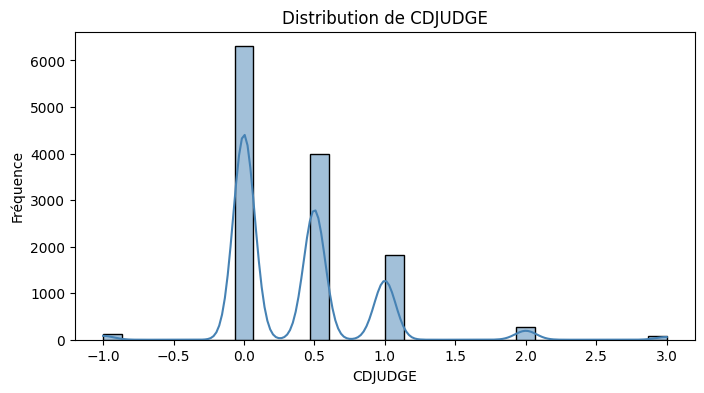

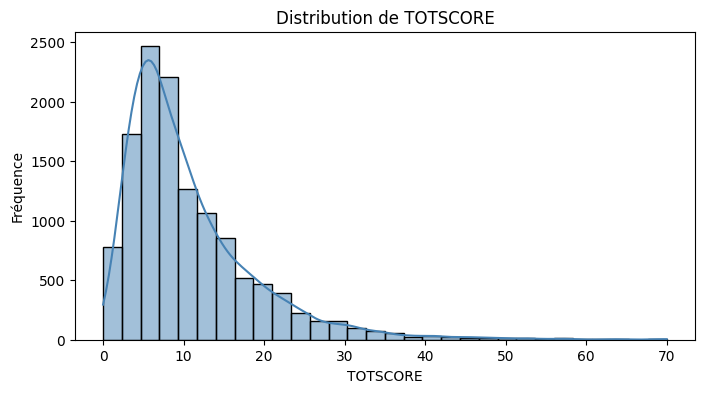

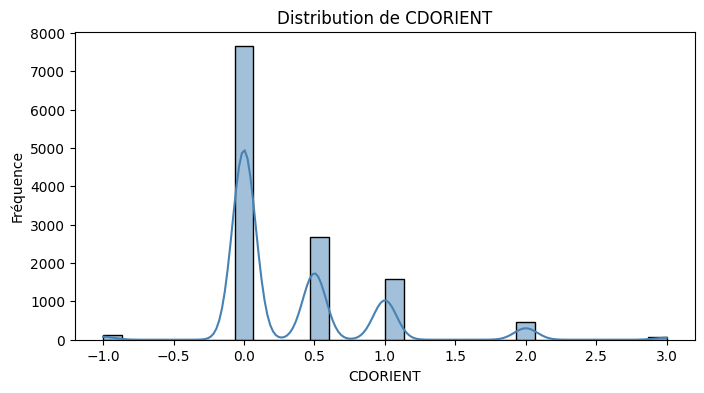

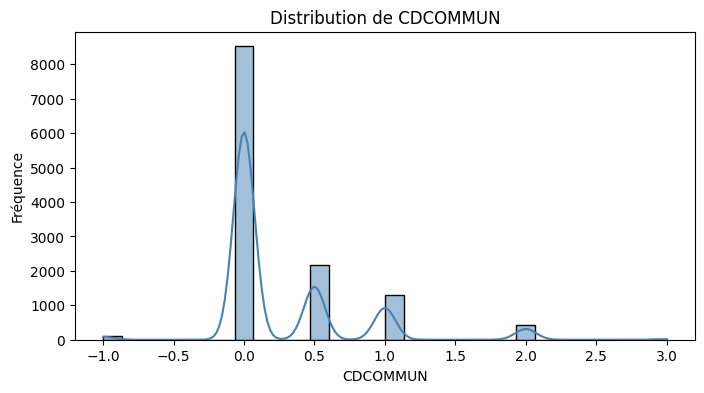

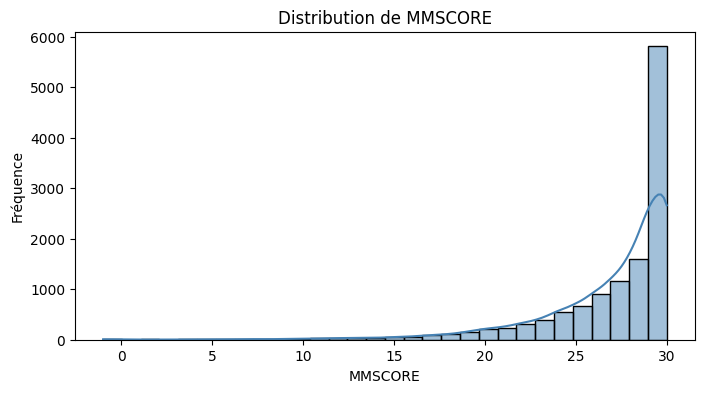

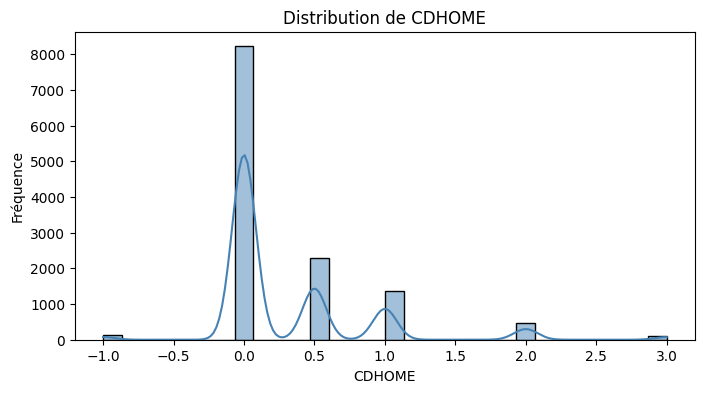

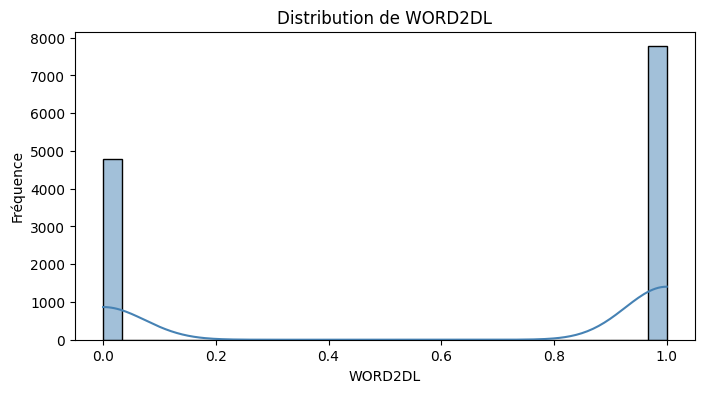

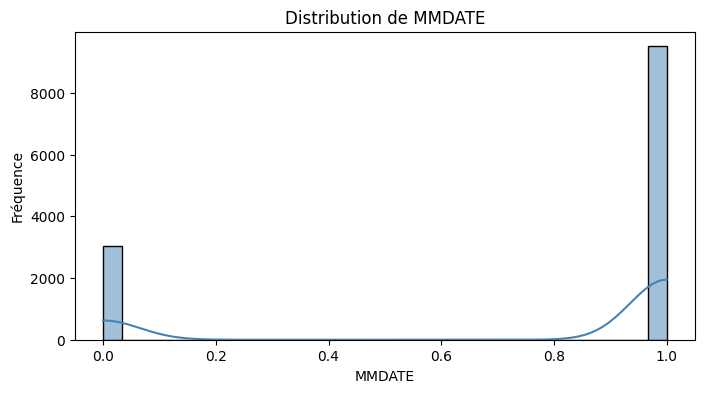

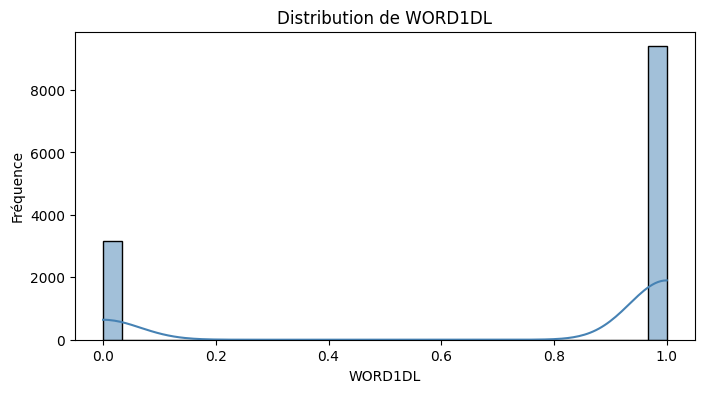

In [ ]:
# 1. variables numériques
num_cols = df.select_dtypes(include=np.number).columns

# 2. enlever la cible
num_cols = [c for c in num_cols if c != "DIAGNOSIS"]

# 3. filtrer variables trop manquantes (ex : > 30%)
num_cols = [c for c in num_cols if df[c].isna().mean() < 0.3]

# 4. corrélation avec la cible (pour choisir les top variables)
corr = df.corr(numeric_only=True)["DIAGNOSIS"].abs()

# 5. garder top variables (ex : top 20)
top_cols = corr.sort_values(ascending=False).head(20).index
top_cols = [c for c in top_cols if c in num_cols]

# 6. histoplots sans la cible
for col in top_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=col,
        kde=True,          # courbe de densité
        bins=30,           # nombre de bins
        color="steelblue"
    )

    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")

    plt.show()


## 8. Boxplots (détection outliers)
Certaines variables présentent des valeurs extrêmes

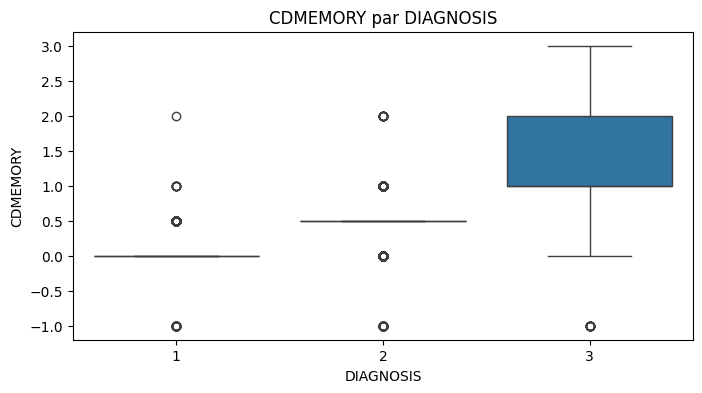

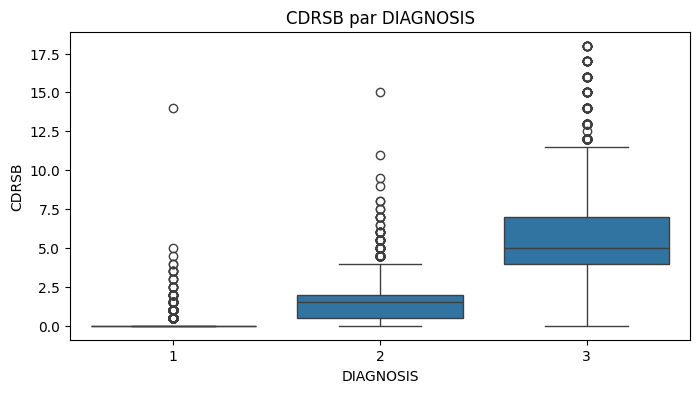

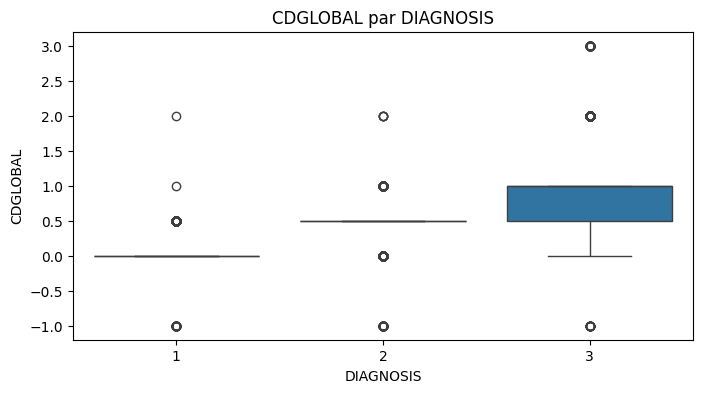

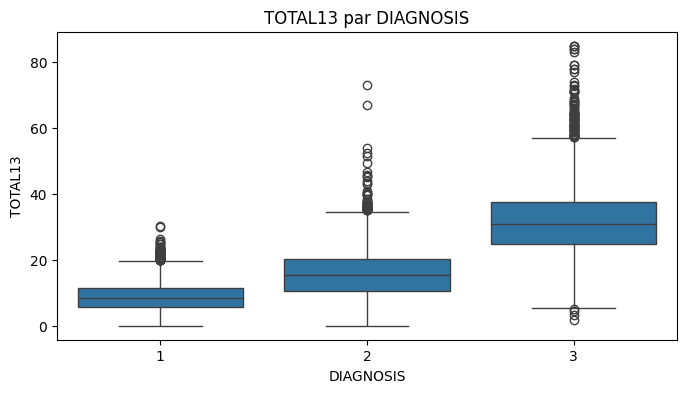

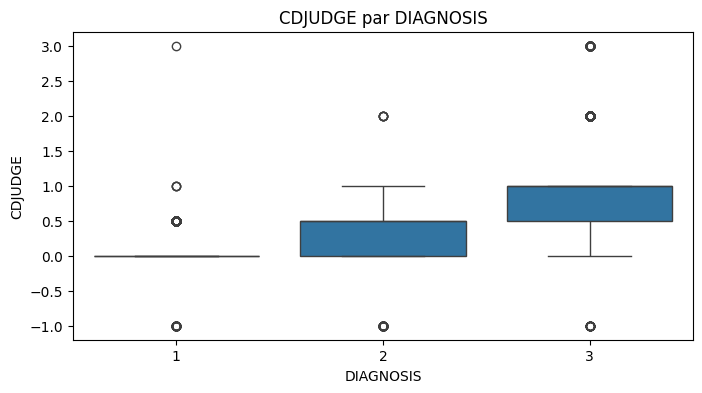

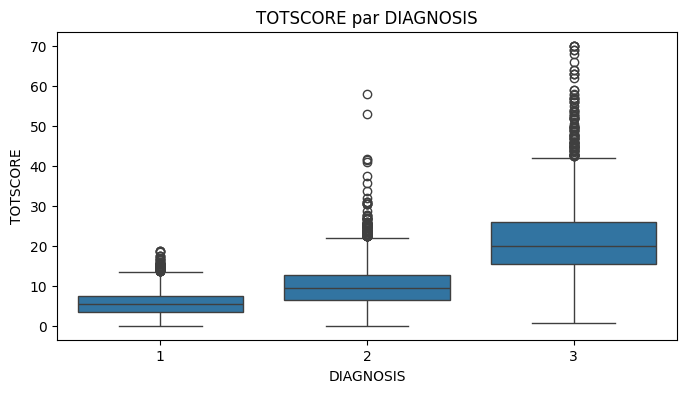

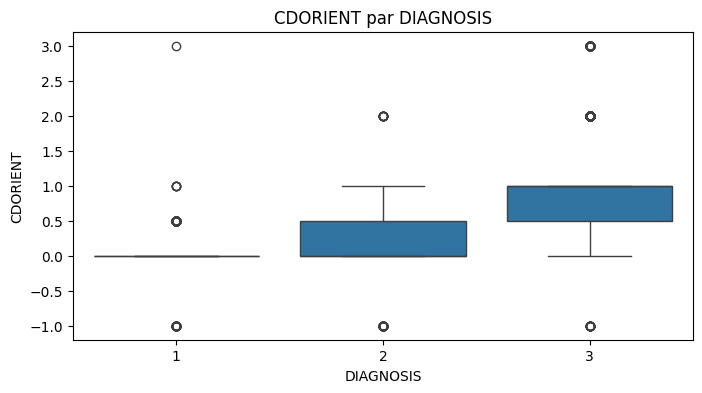

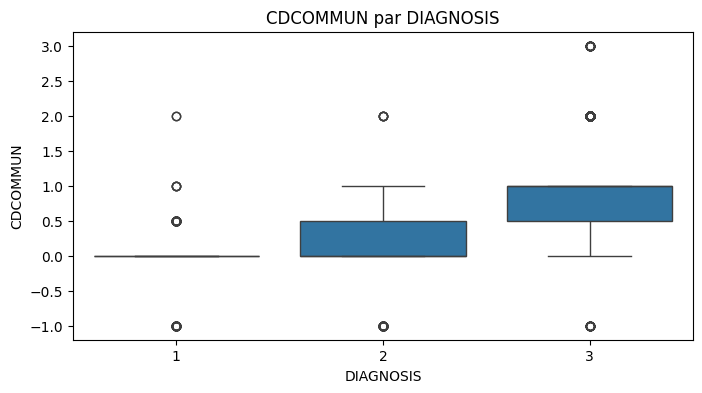

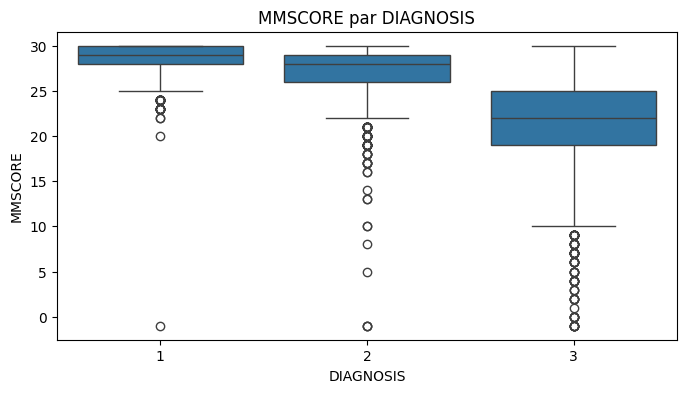

In [27]:
# 1. variables numériques
num_cols = df.select_dtypes(include=np.number).columns
 
# 2. enlever la cible
num_cols = [c for c in num_cols if c != "DIAGNOSIS"]
 
# 3. filtrer variables trop manquantes (ex : > 30%)
num_cols = [c for c in num_cols if df[c].isna().mean() < 0.3]
 
# 4. corrélation avec la cible
corr = df.corr(numeric_only=True)["DIAGNOSIS"].abs()
 
# 5. garder top variables (ex : top 12)
top_cols = corr.sort_values(ascending=False).head(15).index
top_cols = [c for c in top_cols if c in num_cols]
 
# 6. boxplots
for col in top_cols:
 
    plt.figure(figsize=(8, 4))
   
    sns.boxplot(x="DIAGNOSIS", y=col, data=df)
   
    plt.title(f"{col} par DIAGNOSIS")
    plt.xlabel("DIAGNOSIS")
    plt.ylabel(col)
   
    plt.show()   
 
 


## 9. Corrélations

In [5]:
# 1. variables numériques
num_cols = df.select_dtypes(include=np.number).columns

# 2. enlever la cible
num_cols = [c for c in num_cols if c != "DIAGNOSIS"]

# 3. filtrer variables trop manquantes (ex : > 30%)
num_cols = [c for c in num_cols if df[c].isna().mean() < 0.3]

# 4. corrélation absolue avec la cible
corr = df.corr(numeric_only=True)["DIAGNOSIS"].abs()

# 5. top 20 corrélations (toutes colonnes)
top20 = corr.sort_values(ascending=False).head(20).index

# 6. filtrer pour ne garder que celles autorisées par tes filtres
top20 = [c for c in top20 if c in num_cols]

# 7. récupérer les valeurs de corrélation correspondantes
top20 = corr[top20].sort_values(ascending=False)

print("Top 20 corrélations (après filtres) :")
print(top20)


Top 20 corrélations (après filtres) :
CDMEMORY    0.778667
CDRSB       0.752892
CDGLOBAL    0.750700
TOTAL13     0.723560
CDJUDGE     0.682610
TOTSCORE    0.682264
CDORIENT    0.674632
CDCOMMUN    0.652732
MMSCORE     0.649152
CDHOME      0.637482
WORD2DL     0.527282
MMDATE      0.525275
WORD1DL     0.517369
Name: DIAGNOSIS, dtype: float64


<Axes: >

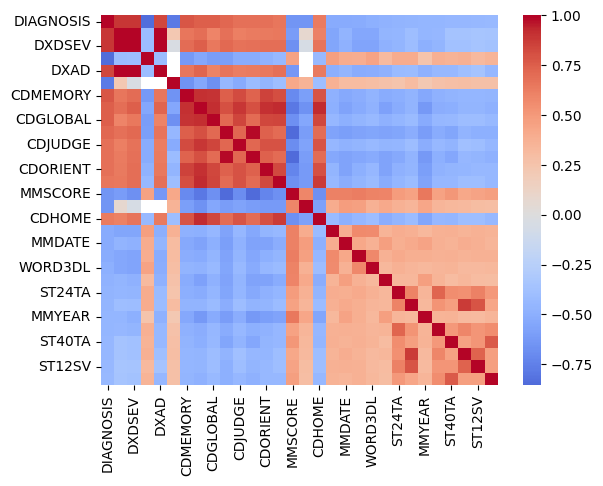

In [10]:
corr = df.corr(numeric_only=True)["DIAGNOSIS"].abs()
top30 = corr.sort_values(ascending=False).head(30).index
sns.heatmap(df[top30].corr(), cmap="coolwarm", center=0)


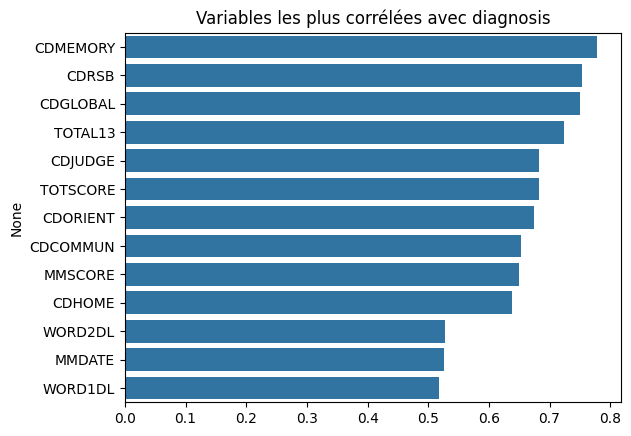

In [58]:
sns.barplot(x=top20.values, y=top20.index)
plt.title("Variables les plus corrélées avec diagnosis")
plt.show()

In [ ]:
# 1. Colonnes numériques uniquement
df_numeric = df.select_dtypes(include=[np.number])

# Ajouter DIAGNOSIS si absent
if 'DIAGNOSIS' not in df_numeric.columns:
    df_numeric = df_numeric.copy()
    df_numeric['DIAGNOSIS'] = df['DIAGNOSIS']

# 2. Corrélation avec la cible
corr_target = df_numeric.corr()['DIAGNOSIS'].abs().drop('DIAGNOSIS').sort_values(ascending=False)

# 3. Matrice de corrélation entre variables (triangle supérieur)
corr_matrix = df_numeric.drop(columns='DIAGNOSIS').corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Identifier les paires redondantes
pairs = []
for col in upper.columns:
    corr_high = upper[col][upper[col] > 0.8].dropna()
    for row, val in corr_high.items():
        corr_row = corr_target.get(row, 0)
        corr_col = corr_target.get(col, 0)
        # On garde celui le plus corrélé avec DIAGNOSIS
        gardee  = row if corr_row >= corr_col else col
        supprimee = col if corr_row >= corr_col else row
        pairs.append({
            'var_A': row,
            'corr_A_vs_target': round(corr_row, 3),
            'var_B': col,
            'corr_B_vs_target': round(corr_col, 3),
            'corr_entre_elles': round(val, 3),
            'gardee': gardee,
            'supprimee': supprimee
        })

# 5. Affichage trié par corrélation entre variables
df_pairs = pd.DataFrame(pairs).sort_values('corr_entre_elles', ascending=False)
print(df_pairs.to_string(index=False))

# 6. Colonnes à supprimer (uniques)
to_drop = set(df_pairs['supprimee'].tolist())
print(f"\nColonnes à supprimer : {len(to_drop)}")
print(f"Colonnes restantes   : {df_numeric.shape[1] - 1 - len(to_drop)}")

      var_A  corr_A_vs_target       var_B  corr_B_vs_target  corr_entre_elles      gardee   supprimee
  PTLANGUN6             0.028      ST97TS             0.096             1.000      ST97TS   PTLANGUN6
  PTLANGWR6             0.329      ST97TS             0.096             1.000   PTLANGWR6      ST97TS
  PTLANGRD6             0.248      ST97TS             0.096             1.000   PTLANGRD6      ST97TS
  PTLANGSP6             0.403      ST97TS             0.096             1.000   PTLANGSP6      ST97TS
  PTLANGUN6             0.028      ST97TA             0.217             1.000      ST97TA   PTLANGUN6
  PTLANGWR6             0.329      ST97TA             0.217             1.000   PTLANGWR6      ST97TA
  PTLANGRD6             0.248      ST97TA             0.217             1.000   PTLANGRD6      ST97TA
  PTLANGSP6             0.403      ST97TA             0.217             1.000   PTLANGSP6      ST97TA
  PTLANGUN6             0.028      ST97SA             0.014             1.000   PT

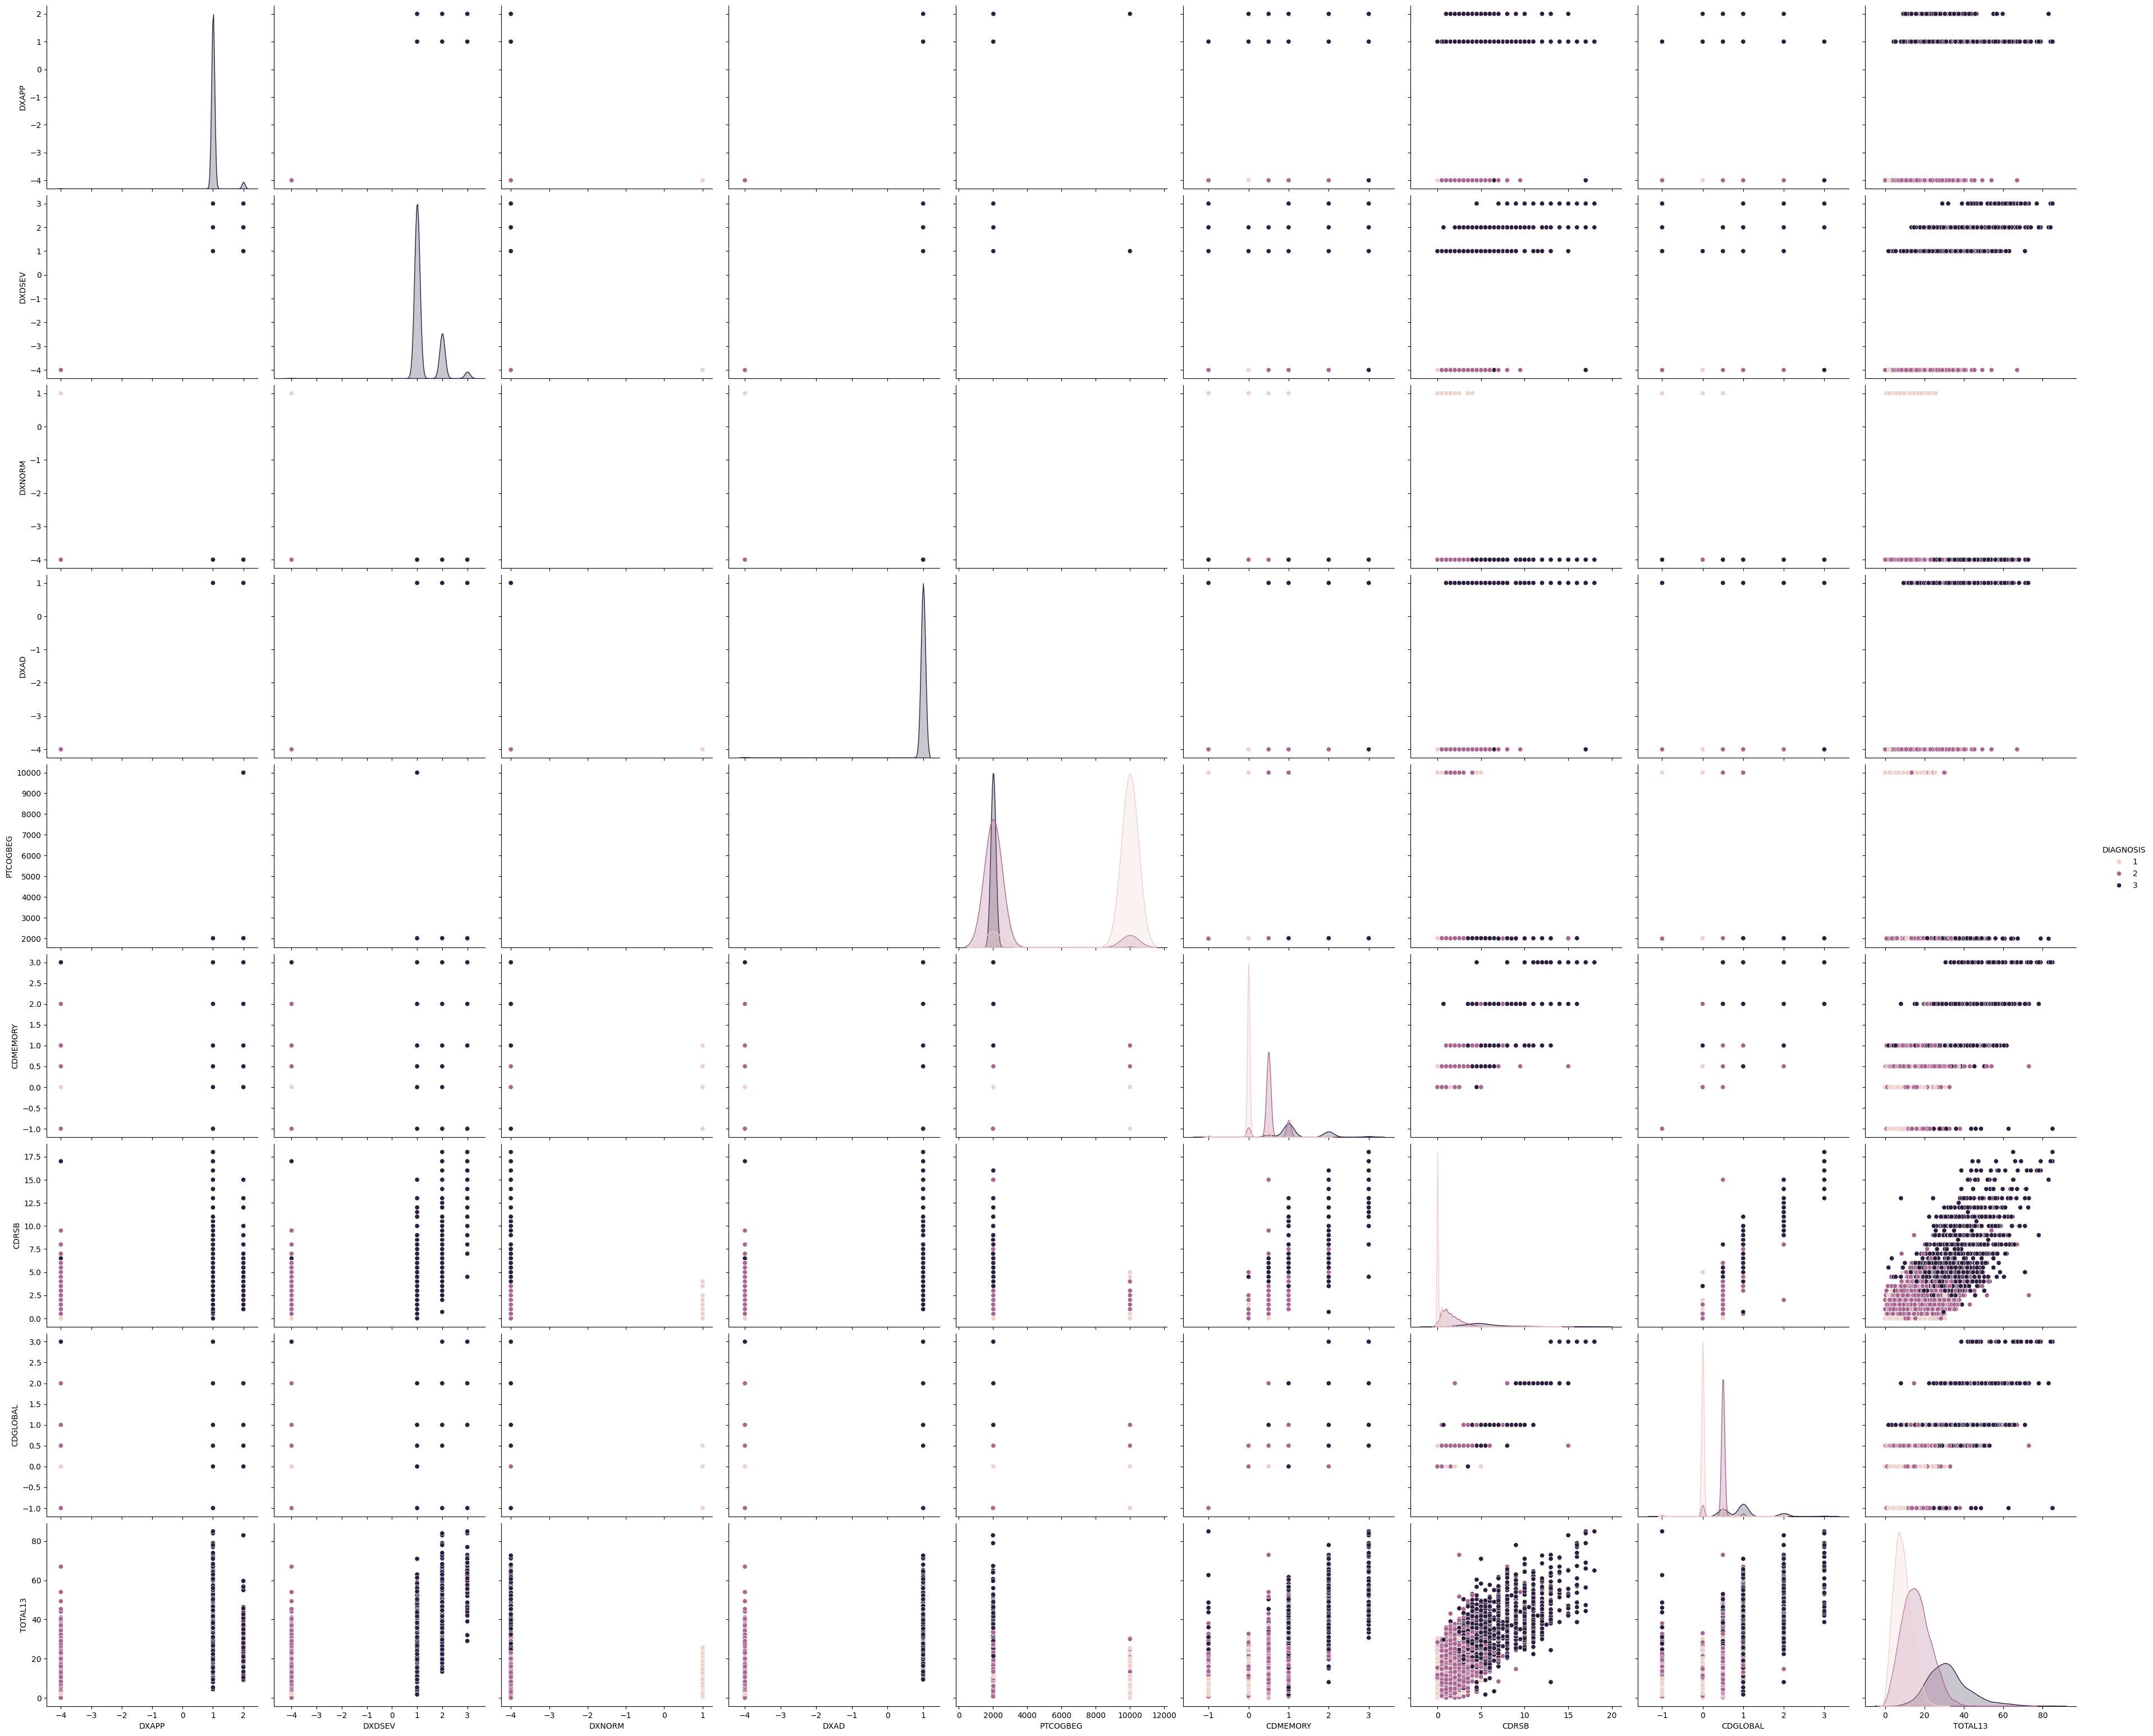

In [69]:
# 1. Corrélations
corr = df.corr(numeric_only=True)['DIAGNOSIS'].abs().sort_values(ascending=False)

# 2. Top 10 colonnes
top_cols = corr.head(10).index.tolist()

# 3. Pairplot agrandi
sns.pairplot(
    df[top_cols],
    hue='DIAGNOSIS',
    height=3.5,
    aspect=1.2
)
plt.show()

## 10. Colonnes constantes

In [ ]:
# Colonnes constantes
[col for col in df.columns if df[col].nunique() <= 1]


['PTADBEG', 'PTOPI']

In [ ]:
# Colonnes quasi-constantes (>= 95% d’une seule valeur)
threshold = 0.99
quasi_const_cols = [col for col in df.columns if df[col].value_counts(normalize=True).values[0] >= threshold]
quasi_const_cols

['LANGUAGE_CODE',
 'DXPDES',
 'DXPCOG',
 'DXPATYP',
 'DXOTHDEM',
 'MHSOURCE',
 'SOURCE',
 'MMWATCH',
 'MMPENCIL',
 'PXABNORM',
 'PTSOURCE',
 'PTADBEG',
 'PTOPI']

In [42]:
for col in df :
    if df[col].nunique() == 0 or col =='MMYEAR':
        print(f'{col :*<30} {df[col].unique()}')

MMYEAR************************ [nan  1.  0.]


In [60]:
print("Nombre de valeurs différentes par colonne :\n",df.nunique().sort_values(ascending=False))

Nombre de valeurs différentes par colonne :
 Id                      14254
IMAGEUID                 8931
ST10CV                   8918
ST154SV                  8915
ST149SV                  8915
ST148SV                  8915
ST147SV                  8915
ST155SV                  8797
ST37SV                   8783
ST96SV                   8770
ST28SA                   8761
ST87sa                   8759
ST17SV                   8720
ST76SV                   8717
ST151SV                  8716
ST150SV                  8709
ST152SV                  8689
ST1SV                    8456
ST128SV                  8454
ST18SV                   8355
ST77SV                   8351
ST61SV                   7578
ST120SV                  7545
ST127SV                  7408
ST112SV                  7300
ST53SV                   7287
ST88SV                   7230
ST30SV                   7201
ST9SV                    7195
ST153SV                  7143
ST29SV                   7139
ST75SV                   

In [63]:
print("Colonnes avec 2 valeur :\n",df.nunique()[df.nunique() == 2])

Colonnes avec 2 valeur :
 DD_CRF_VERSION_LABEL    2
LANGUAGE_CODE           2
DXNORM                  2
DXNODEP                 2
DXMCI                   2
DXDDUE                  2
DXAD                    2
DXDEP                   2
DXOTHDEM                2
IHSURG                  2
IHPRESENT               2
IHONGOING               2
MHSOURCE                2
MHPSYCH                 2
MH2NEURL                2
MH3HEAD                 2
MH4CARD                 2
MH5RESP                 2
MH6HEPAT                2
MH7DERM                 2
MH8MUSCL                2
MH9ENDO                 2
MH10GAST                2
MH11HEMA                2
MH12RENA                2
MH13ALLE                2
MH14ALCH                2
MH15DRUG                2
MH16SMOK                2
MH17MALI                2
MH18SURG                2
MH19OTHR                2
DONE                    2
SOURCE                  2
MMDATE                  2
MMYEAR                  2
MMMONTH                 2
MMDAY       

## 11. Analyse des variables catégorielles

In [ ]:
obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    if df[col].nunique() < 3:
        print(f'{col:*<30} {df[col].unique()}')

#FIELD_STRENGTH = intensité du champ magnétique de l’IRM
#STATUS = status de l'examen
#FSVER = Version du logiciel / firmware de l’IRM
#Le dataset contient très peu de variables catégorielles utilisables. Celles qui étaient exploitables ont déjà été converties dans un format numérique.

DD_CRF_VERSION_LABEL********** <StringArray>
[nan, 'list1', 'v1']
Length: 3, dtype: str
LANGUAGE_CODE***************** <StringArray>
[nan, 'e', 's']
Length: 3, dtype: str
DONE************************** <StringArray>
[nan, '1', '0']
Length: 3, dtype: str
SOURCE************************ <StringArray>
[nan, '1', '2']
Length: 3, dtype: str
FIELD_STRENGTH**************** <StringArray>
[nan, '1.5T', '3T']
Length: 3, dtype: str
STATUS************************ <StringArray>
[nan, 'partial', 'complete']
Length: 3, dtype: str
FSVER************************* <StringArray>
[nan, '7.2.0', '7.4.1']
Length: 3, dtype: str
TEMPQC************************ <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
FRONTQC*********************** <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
PARQC************************* <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
INSULAQC********************** <StringArray>
[nan, 'Fail', 'Pass']
Length: 3, dtype: str
OCCQC************************* <S

C:\Users\Magalie\AppData\Local\Temp\ipykernel_19064\1831255985.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object']).columns


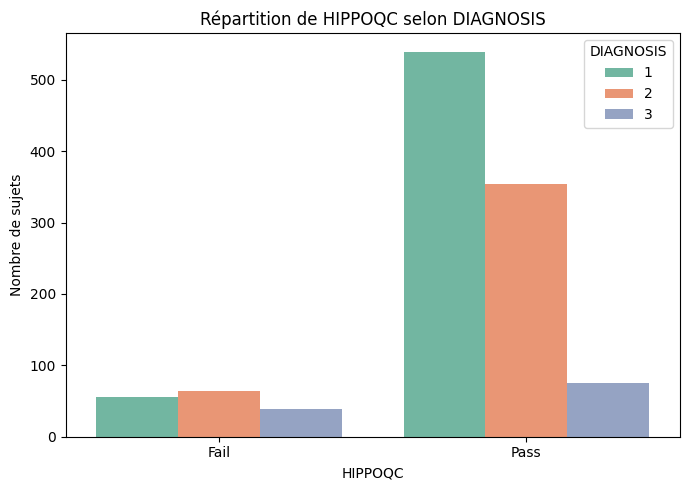

In [16]:

plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='HIPPOQC',
    hue='DIAGNOSIS',
    palette='Set2'
)

plt.title("Répartition de HIPPOQC selon DIAGNOSIS")
plt.xlabel("HIPPOQC")
plt.ylabel("Nombre de sujets")
plt.tight_layout()
plt.show()


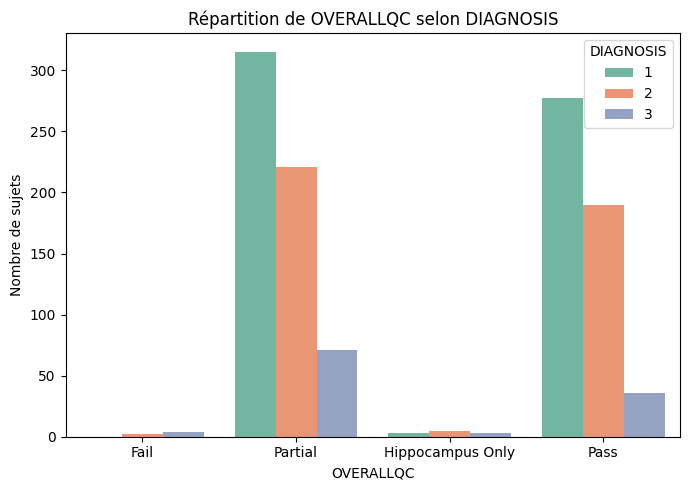

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='OVERALLQC',
    hue='DIAGNOSIS',
    palette='Set2'
)

plt.title("Répartition de OVERALLQC selon DIAGNOSIS")
plt.xlabel("OVERALLQC")
plt.ylabel("Nombre de sujets")
plt.tight_layout()
plt.show()

<Axes: >

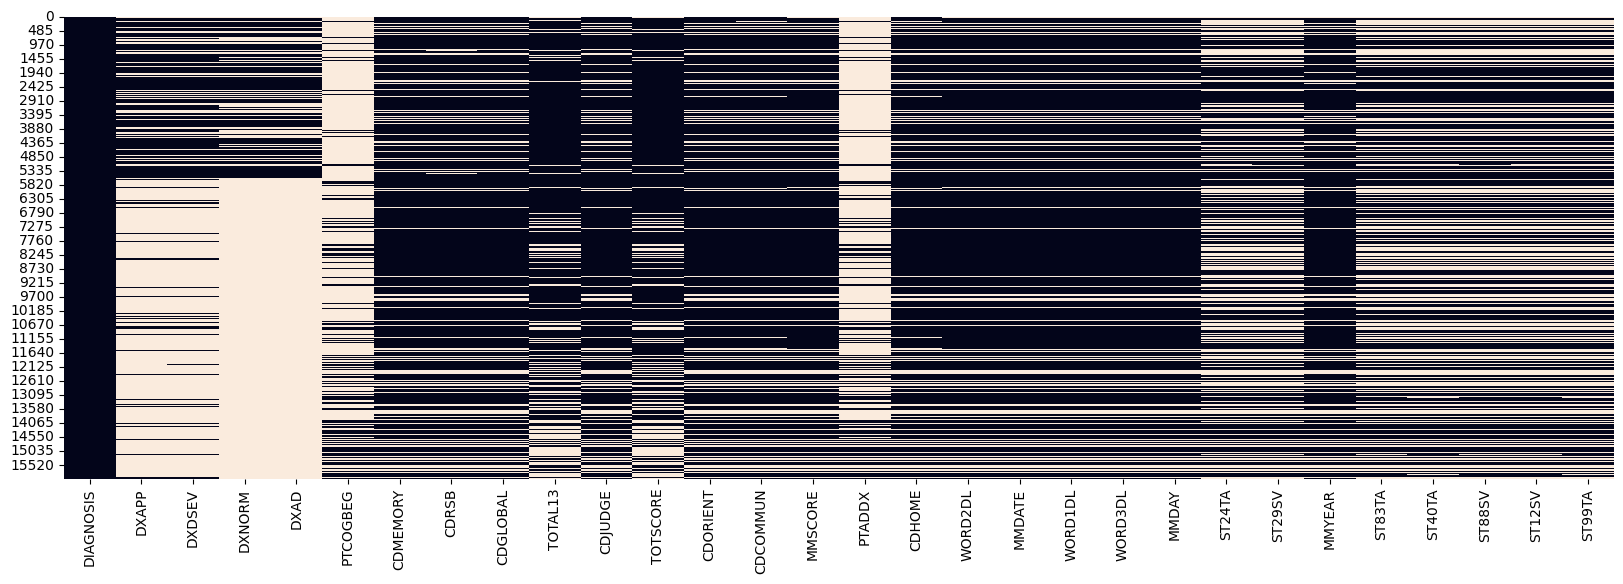

In [11]:
plt.figure(figsize=(20,6))
sns.heatmap(df[top30].isna(),cbar=False) #si les lignes sont continues possible relation entre les variables

## 12. Analyse longitudinale

In [29]:
# Nombre patient
print("Nombre de patients :", df['RID'].nunique())




Nombre de patients : 3777


In [31]:
moyenne_visites = df.groupby('RID')['VISDATE'].count().mean()
print("Nombre moyen de visites par patient :", moyenne_visites)

Nombre moyen de visites par patient : 4.168387609213662


In [52]:
#Visualisation du MMSCORE score des patients avec plusieurs visites
#Le MMSCORE a tendance à baisser au fils des visites
# Compter le nombre de visites par patient
visits_per_patient = df.groupby('RID')['VISDATE'].count()

# Sélectionner 20 patients avec plusieurs visites
multi_visit_patients = visits_per_patient[visits_per_patient > 1].index.tolist()[:20]

# Filtrer et trier
df_tracking = df[df['RID'].isin(multi_visit_patients)].sort_values(['RID', 'VISDATE'])

# Nettoyage du MMSE
df_tracking['MMSCORE_clean'] = df_tracking['MMSCORE'].replace([-4, -1], np.nan)

# Graphique interactif
fig = go.Figure()

for patient in multi_visit_patients:
    patient_data = df_tracking[df_tracking['RID'] == patient]
    fig.add_trace(go.Scatter(
        x=patient_data['VISDATE'],
        y=patient_data['MMSCORE_clean'],
        mode='lines+markers',
        name=f'Patient {patient}',
        showlegend=False,
        opacity=0.7
    ))

fig.update_layout(
    title='Évolution longitudinale du MMSE par patient (20 patients)',
    xaxis_title='Date de visite',
    yaxis_title='Score MMSE',
    height=500,
    width=1000,
    )

fig.show()


RECOMMANDATIONS POUR LE PREPROCESSING ET LA MODÉLISATION
 
1. Gestion des valeurs manquantes <br>
Convertir les codes ADNI non standard (-4, -1, 9999) en NaN avant tout traitement.<br>
Envisager l’exclusion des variables présentant plus de 50 % de valeurs manquantes, sauf justification clinique.<br>
Imputation : variables numériques imputées par la médiane en raison des outliers, variables catégorielles imputées par le mode.<br>

3. Variable catégoriellles<br>
Certains float seraient plutôt des variables catégorielles MMDATE, WORD1DL, etc ...0= Incorrect; 1 = Correct.<br>
Panda les transformes en float car il y a des Nan.<br>
 
2. Variable cible <br>
Cible primaire : DIAGNOSIS (1 = Normal, 2 = MCI, 3 = AD).<br>
Pour la détection précoce du risque Alzheimer, nous allons regrouper MCI et AD en une classe unique.<br>
Nouvelle cible binaire : 0 = Sain (≈ 40 %), 1 = À risque Alzheimer (≈ 60 %).<br>
La distribution a été évaluée déséquilibre léger prevoir une stratification lors du split train/test.<br>
 
3. Variables prédictives principales  <br>
Supprimer les colonnes techniques : RID, VISCODE, VISCODE2, PTID, VISDATE, Id, SITEID, USERDATE, USERDATE2, update_stamp, EXAMDATE, PHASE, RUNDATE.<br>
Détecter les features fortement corrélées par paire et conserver la plus corrélée à la cible.<br>
Variables les plus corrélées : PTCOGBEG, CDRSB, TOTAL13,ST89SV.<br>
Inclure les principaux scores cognitifs : MMSE, TOTSCORE, TOTAL13.<br>
Inclure les variables physiologiques pertinentes (IMC, pression artérielle, pression pulsée).<br>
Exclure toutes les variables DX* (DXAPP, DXDSEV, DXAD, DXMDES…) pour éviter la fuite de données.<br>
Seule la cible DIAGNOSIS est conservée.<br><br>
Au vue du nombre important de colonnes et du retard dans le projet, nous avons fait des recherches métier et avons choisi de garder les features suivantes :<br>
- Cognitive : CDRSB, CDGLOBAL, CDMEMORY, CDJUDGE, CDCOMMUN, CDHOME, TOTSCORE, TOTAL13, WORD2DL, WORD1DL, MMSCORE et CDCARE<br>
- Physique : VSWEIGHT, VSHEIGHT, VSBPSYS, VSBPDIA, VSPULSE, VSWTUNIT, VSHTUNIT<br>
- Imagerie : ST101SV, ST112SV, ST120SV, ST125SV<br>
- Démographique : PTGENDER, PTMARRY, PTHAND, PTEDUCAT<br>
- Médicale : MH4CARD, MH9ENDO, MH14ALCH, MH16SMOK, MH2NEURL, MHPSYCH, MH11HEMA, MH6HEPAT<br>
 
4. Détection des anomalies  <br>
Décision selon la plausibilité clinique : clipping si la valeur extrême est une erreur probable mais exploitable, exclusion si la valeur est cliniquement incohérente.<br>
 
5. Feature Engineering  <br>
Les calculs suivants seront effectués<br>
Indice de Masse Corporelle : poids/taille en m2<br>
La normalisation des unités de mesure pour la taille et le poids sera effectuée en amont afin d’harmoniser les données issues des différentes sources ADNI.<br>
Tension artérielle = systolic mmHg / diastolic mmHg<br>
Pression pulsée = systolic mmHg - diastolic mmHg<br>
 
6. Alerte ADNI<br>
Tous les patients avec un PTID du type 381_S_10### doivent être supprimés car les données sont de mauvaise qualité (message d'alerte sur le site ADNI).<br>